# Biologically Inspired Neural Gadget Controller Demos
This notebook is designed as a easy einterface to call the functions that we have defined

In [87]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

from ripser import ripser

from data_loader import (load_participants_info,
                         load_event_descriptions,
                         load_behavioral_data,
                         preprocess_data,
                         preprocess_data_stress,
                         preprocess_data_duration
                         )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set seed for reproduciability: 42, 400, 100

In [88]:
import random
import numpy as np
import torch

def set_seed(seed):
    """Sets seed for reproducibility across random, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed) 
    print(f"Seed set to {seed} for reproducibility!")

random_seed = 42
set_seed(random_seed)

Seed set to 42 for reproducibility!


# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [89]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [90]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)

subject_id = None
X_stress = preprocess_data_stress(df_behavior, condition="AROUSING", subject_id=subject_id)
X_neurtal = preprocess_data_stress(df_behavior, condition="NEUTRAL", subject_id=subject_id)
X_long = preprocess_data_duration(df_behavior, duration="long", subject_id=subject_id)
X_short = preprocess_data_duration(df_behavior, duration="short", subject_id=subject_id)

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [91]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=random_seed)

X_stress_train, X_stress_test = train_test_split(X_stress, test_size=0.2, random_state=random_seed)
X_neutral_train, X_neutral_test = train_test_split(X_neurtal, test_size=0.2, random_state=random_seed)
X_long_train, X_long_test = train_test_split(X_long, test_size=0.2, random_state=random_seed)
X_short_train, X_short_test = train_test_split(X_short, test_size=0.2, random_state=random_seed)

# Training

In [92]:
from train import (train_feed_forward_nn,
                   train_vanilla_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.10090765357017517
Epoch 100, Loss: 0.047413088381290436
Epoch 200, Loss: 0.04581799730658531
Epoch 300, Loss: 0.04473387077450752
Epoch 400, Loss: 0.04400461167097092
Epoch 500, Loss: 0.0425226166844368
Epoch 600, Loss: 0.04233134910464287
Epoch 700, Loss: 0.04185999557375908
Epoch 800, Loss: 0.04127867892384529
Epoch 900, Loss: 0.041449274867773056
Epoch 1000, Loss: 0.04023334011435509
Epoch 1100, Loss: 0.0400179922580719
Epoch 1200, Loss: 0.04042331501841545
Epoch 1300, Loss: 0.03948726877570152
Epoch 1400, Loss: 0.03934133052825928
Epoch 1500, Loss: 0.03943813592195511
Epoch 1600, Loss: 0.03904133290052414
Epoch 1700, Loss: 0.038755472749471664
Epoch 1800, Loss: 0.03919144347310066
Epoch 1900, Loss: 0.03796669840812683
Training complete!
Evaluating Model: FeedForwardNN


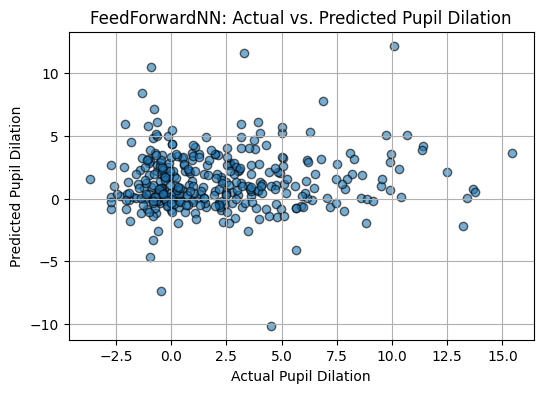

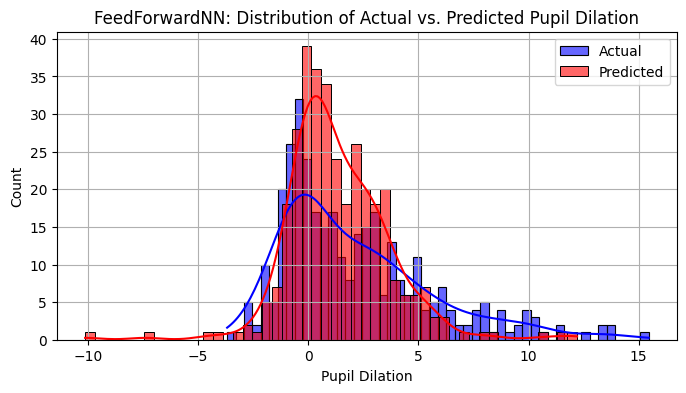

FeedForwardNN - Pearson Correlation: 0.0654


In [93]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

In [94]:
# model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
# evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## FF Gadget Model

Epoch 0, Loss: 0.053592


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.035662
Epoch 200, Loss: 0.017004
Early stopping triggered at epoch 296
Training complete!
Evaluating Model: FFGadgetController


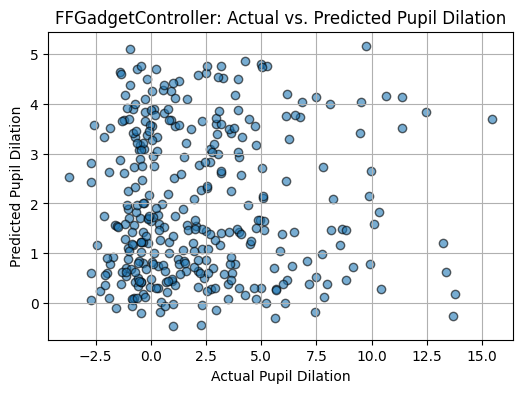

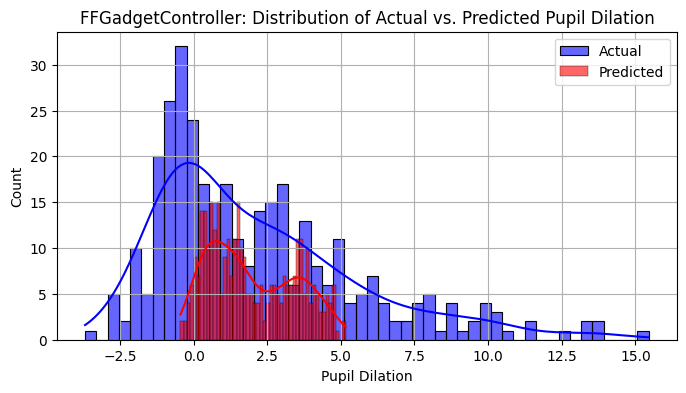

FFGadgetController - Pearson Correlation: 0.0219


In [95]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=124, patience=200)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

We can adjust the uncertainty scale, which is deemed to be consisting of having certain randomness in the action (higher entropy, less loss, favoring more random actions)

Epoch 0, Loss: 0.846013


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.055789
Early stopping triggered at epoch 145
Training complete!


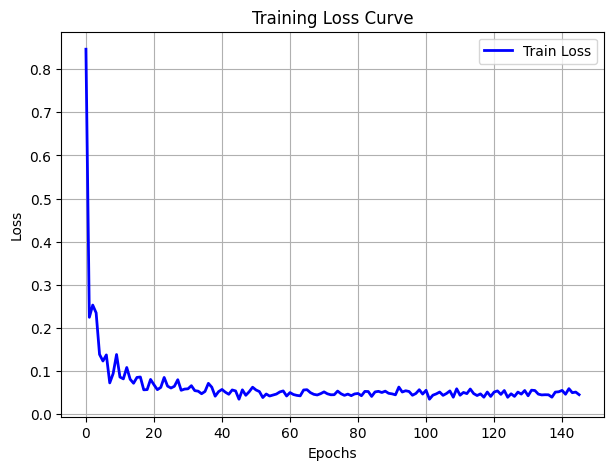

Evaluating Model: FFGadgetUncertainController
Adjusting prev_LC size: torch.Size([256, 256]) -> torch.Size([340, 256])


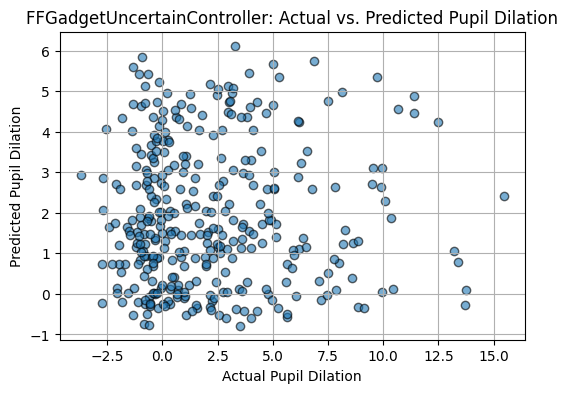

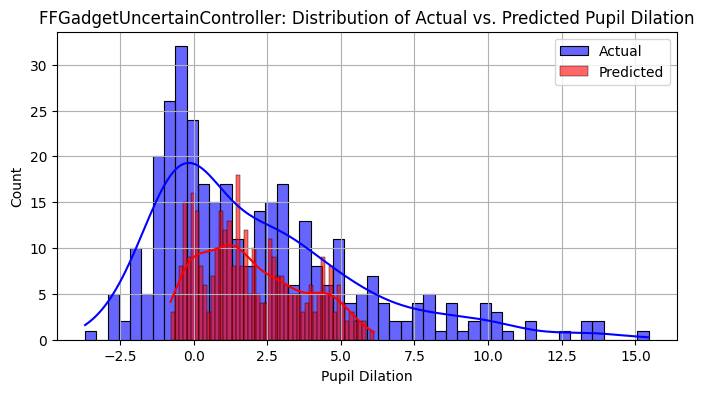

FFGadgetUncertainController - Pearson Correlation: 0.0288


In [96]:
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=100, entropy_scale=0.2)
evaluate_model(ff_uncertain_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# Analysis of the Networks

In [97]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

## Feed-Forward Neural Networks

In [98]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

In [99]:
# pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## Feed-Forward Neural Gadget Controller

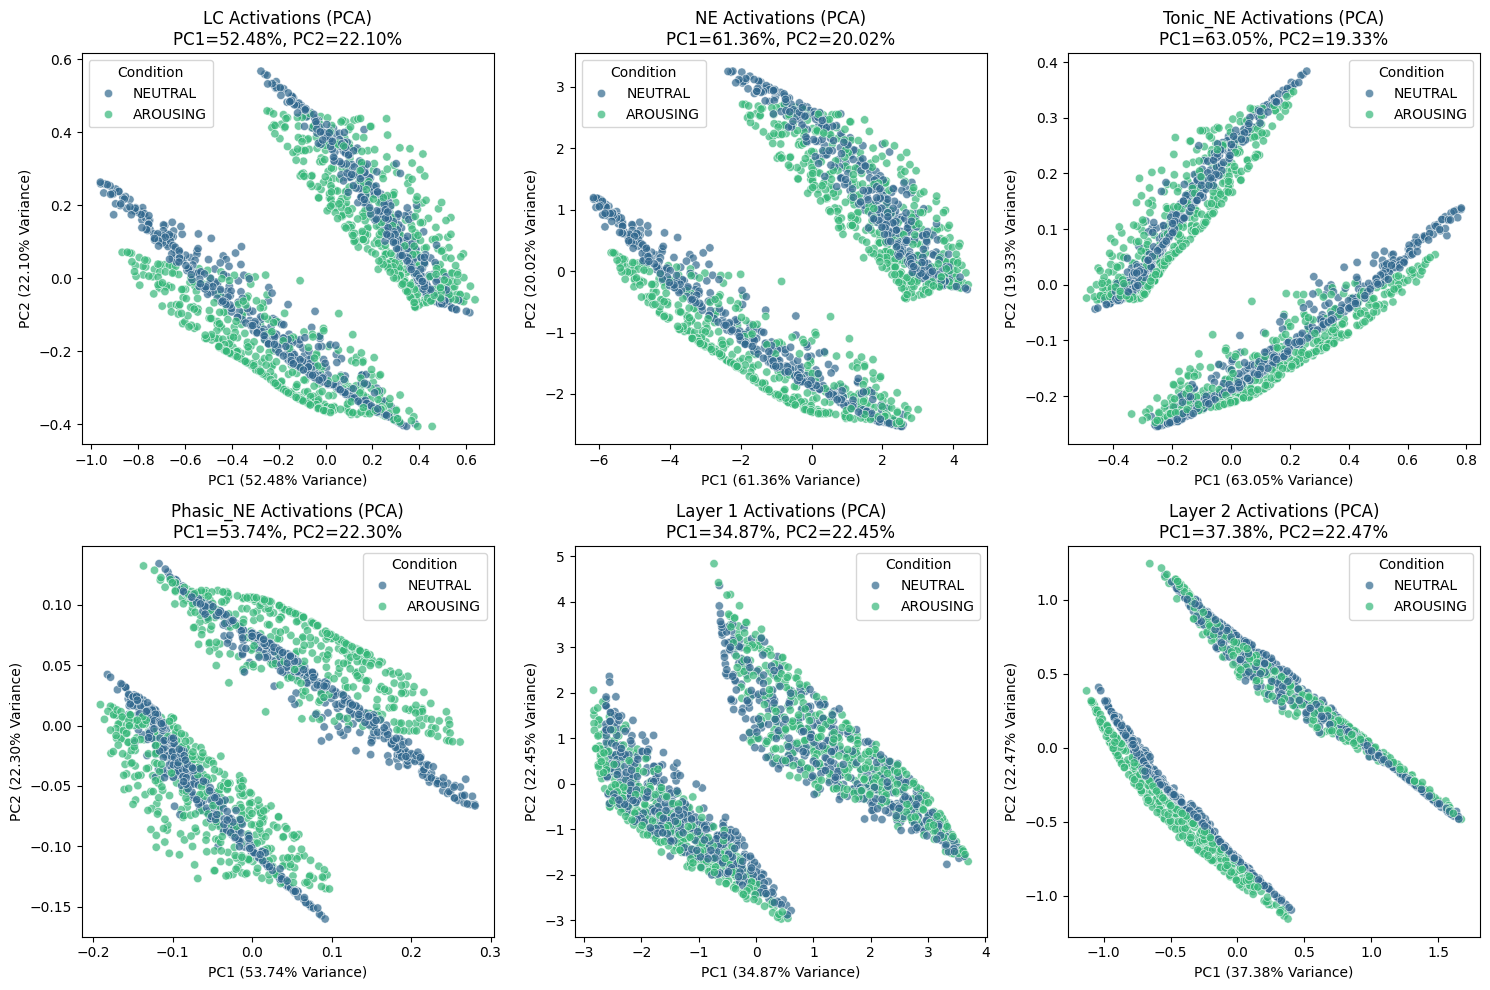

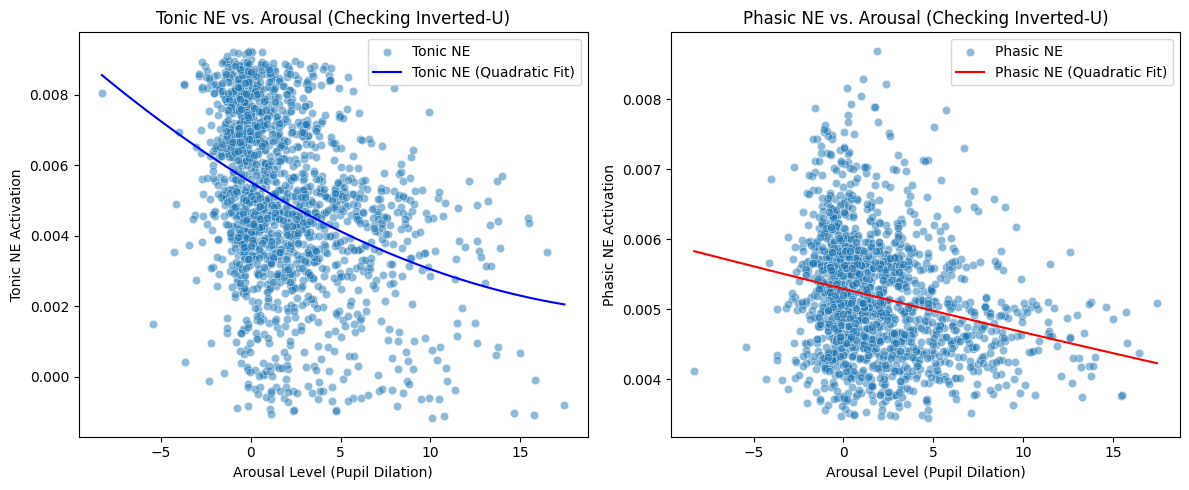


 Pearson Correlation with Actual Pupil Dilation:
LC: -0.081
NE: 0.210
Tonic_NE: -0.355
Phasic_NE: -0.242
Layer 1: 0.048
Layer 2: 0.099
Predicted Pupil Dilation: 0.437


In [100]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Feed-Forward Neural Gadget Uncertainty Controller

Adjusting prev_LC size: torch.Size([340, 256]) -> torch.Size([1699, 256])
Pupil Dilation MAE: 2.1603
Pupil Dilation MSE: 8.2347


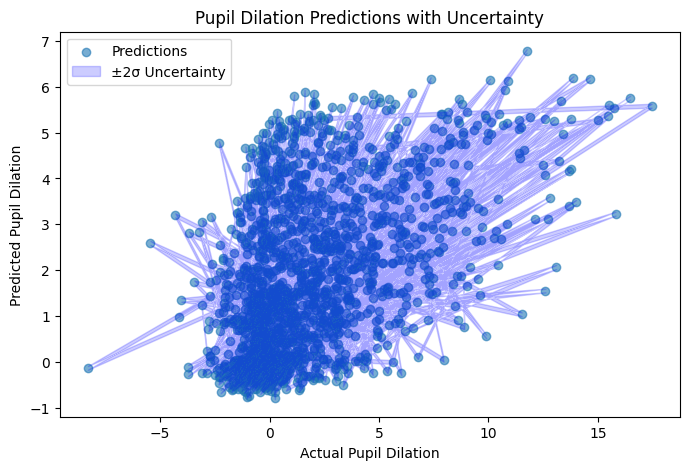

In [101]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

# Maniforlds Projections Nalaysis for Feed-Forward Neural Gadget Uncertainty Controller

In [102]:
from analysis.analysis import (extract_activations_gadget,
                               compute_mapper_graph,
                               compute_persistent_homology,
                               compute_persistent_homology_overlay,
                               compute_mapper_graph_overlay,
                               plot_manifold_projection,
                               construct_activation_graph,
                               plot_activation_graph,
                               compute_persistence_distance_df,
                               compute_persistence_hypothesis_test,
                               compare_persistence_lifetimes,
                               plot_birth_death_distributions,
                               hypothesis_test_persistence_distributions,
                               compute_autocorrelation,
                               compute_activation_entropy,
                               compute_topological_silhouette,
                               compute_betti_curves,
                               time_delay_embedding_multidim,
                               compute_persistent_homology_overlay_with_delay)

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([170, 256])
Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([171, 256])


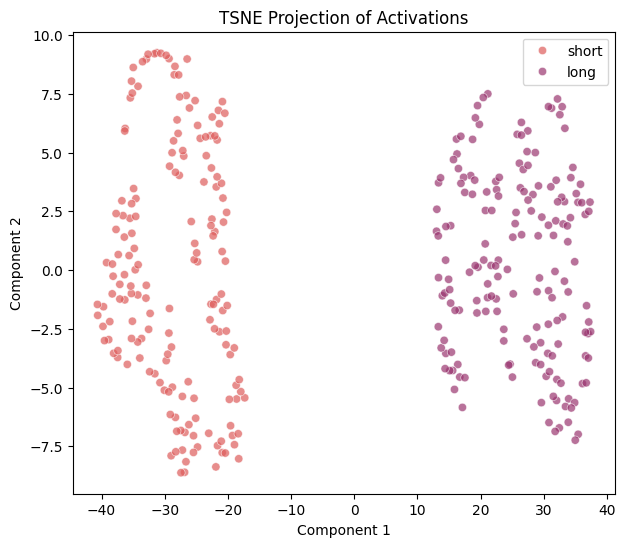

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


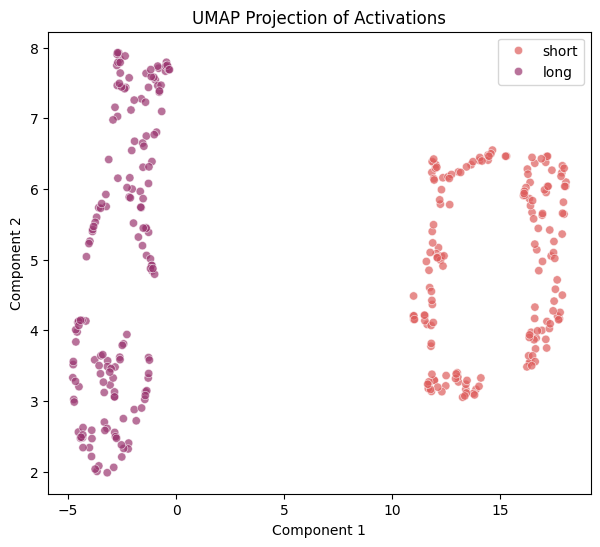

In [103]:
activations_short = extract_activations_gadget(ff_uncertain_gadget, X_short_test)
activations_long = extract_activations_gadget(ff_uncertain_gadget, X_long_test)

all_activations = np.vstack([activations_short["LC"], activations_long["LC"]])
labels = np.array(["short"] * len(activations_short["LC"]) + ["long"] * len(activations_long["LC"]))

# t-SNE projection
plot_manifold_projection(all_activations, labels, method="tsne")

# UMAP projection
plot_manifold_projection(all_activations, labels, method="umap")

## Cosine Similarity Graph

We create an `cosine similarity` graph by connecting similar components in the vector space accoridng to certain similarity threshold.

Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([848, 256])
Adjusting prev_LC size: torch.Size([848, 256]) -> torch.Size([851, 256])


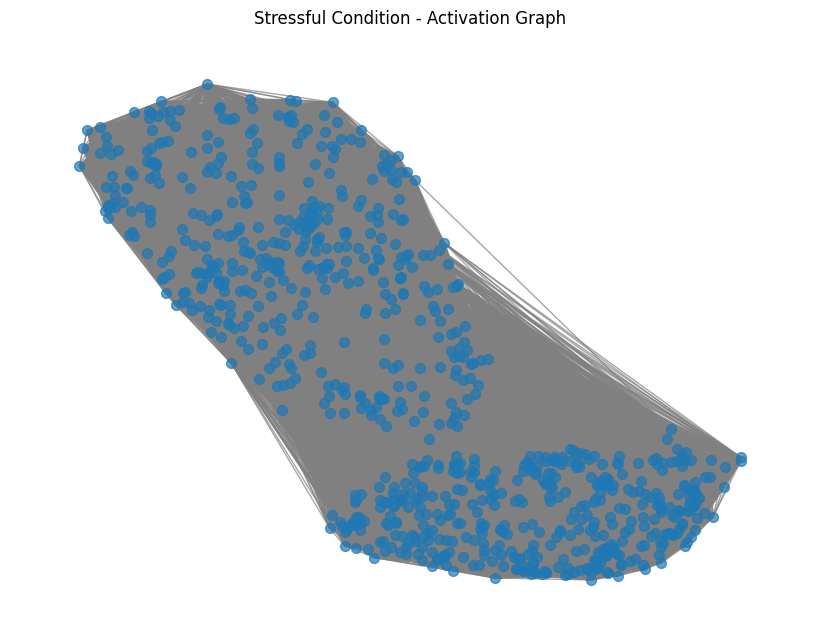

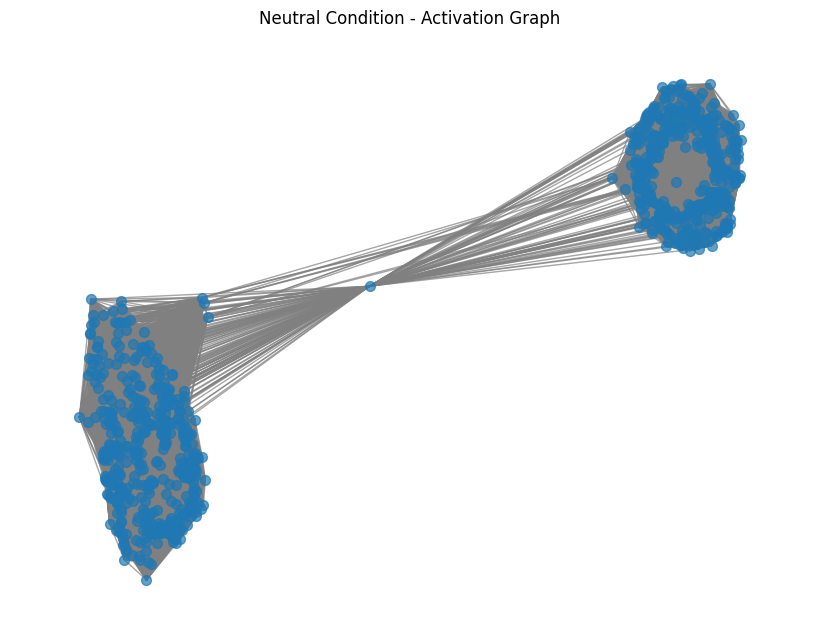

In [104]:
activations_stress = extract_activations_gadget(ff_uncertain_gadget, X_stress)
activations_neutral = extract_activations_gadget(ff_uncertain_gadget, X_neurtal)

G_stress = construct_activation_graph(activations_stress["LC"], threshold=0.96)
G_neutral = construct_activation_graph(activations_neutral["LC"], threshold=0.96)

plot_activation_graph(G_stress, title="Stressful Condition - Activation Graph")
plot_activation_graph(G_neutral, title="Neutral Condition - Activation Graph")

The stressful condition seems to be stuck in the same mode of LC activation, clustered in activation space. Remanber that LC is the controller of the rest of the model and the data here is temporal across 9 participans, so we are thinking an average evolve of `thoughts` here.

## Homology Analyiss
Conducting a persistent homology analysis, which seems to work with the `uncertainty` control model but not other models.

- Formation o higher dimension cyclic loops definately exist

Adjusting prev_LC size: torch.Size([851, 256]) -> torch.Size([1699, 256])
Analyzing LC activations...


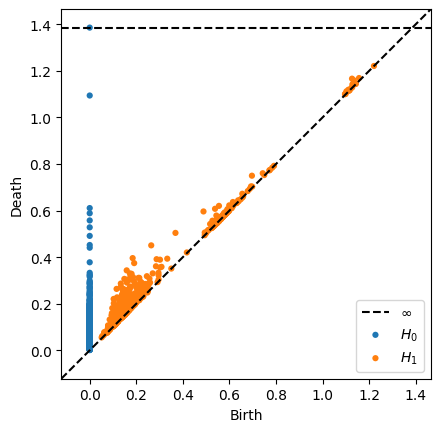

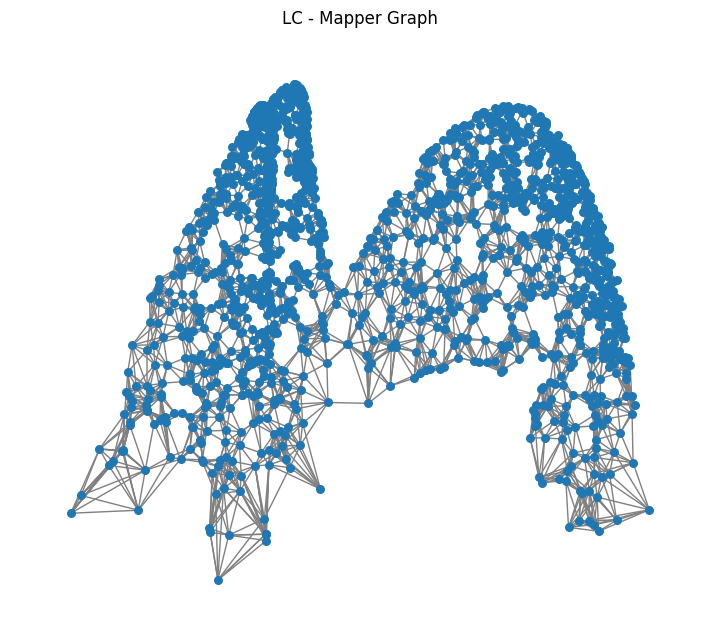

Analyzing NE activations...


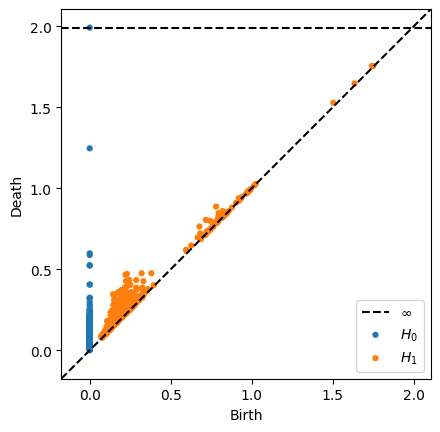

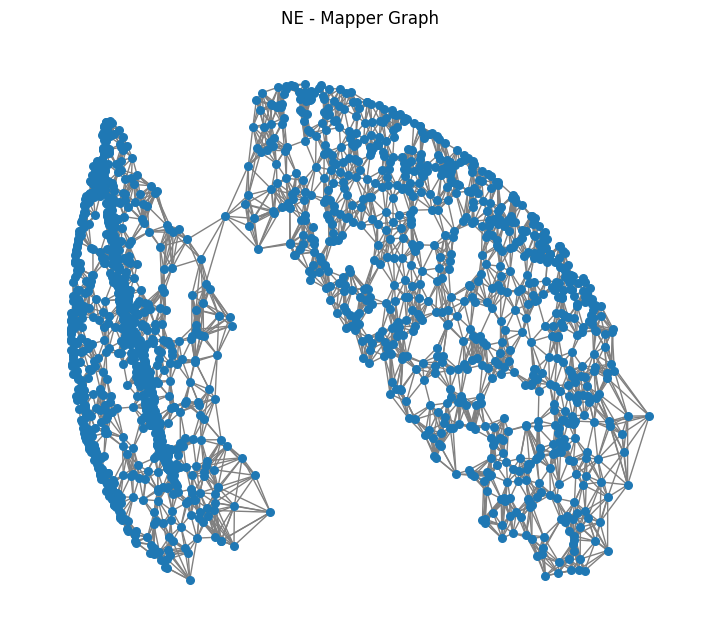

Analyzing Tonic_NE activations...


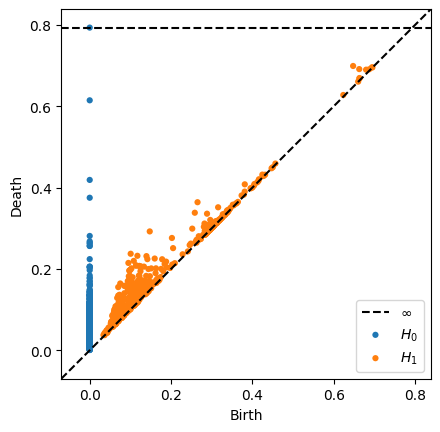

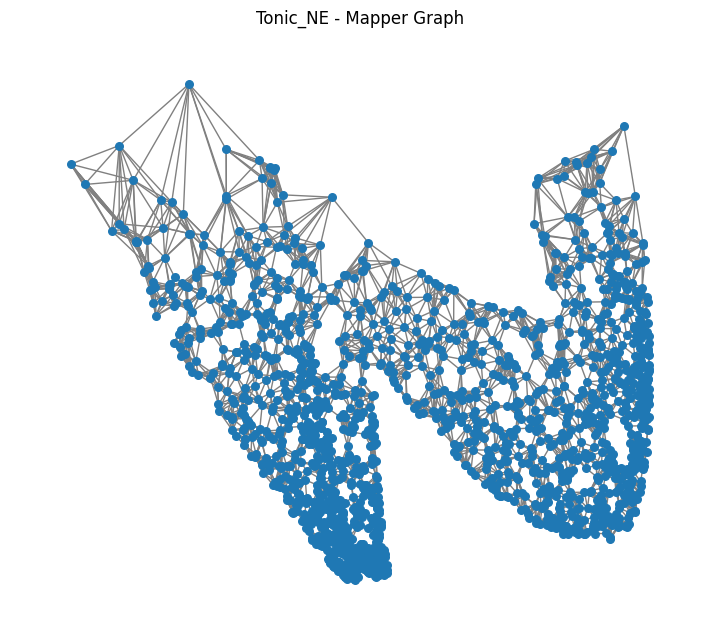

Analyzing Phasic_NE activations...


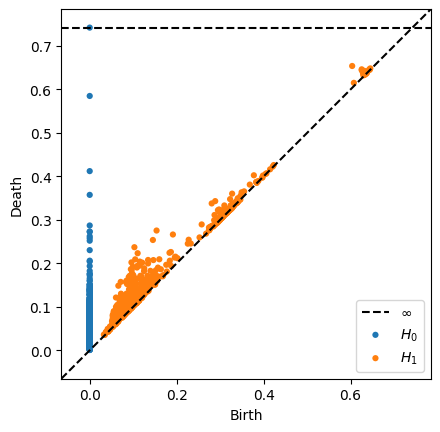

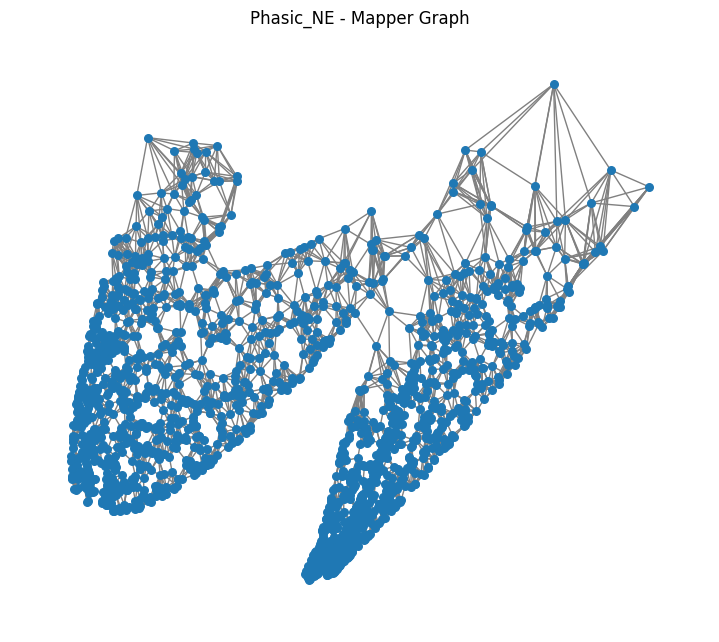

Analyzing Hidden_1 activations...


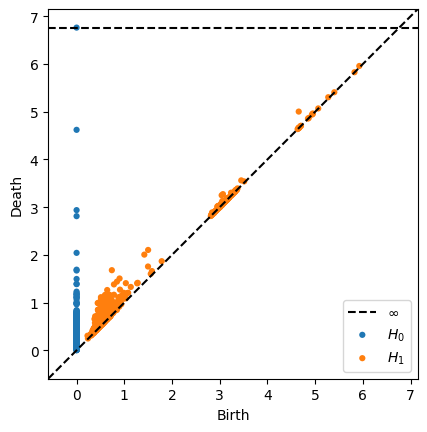

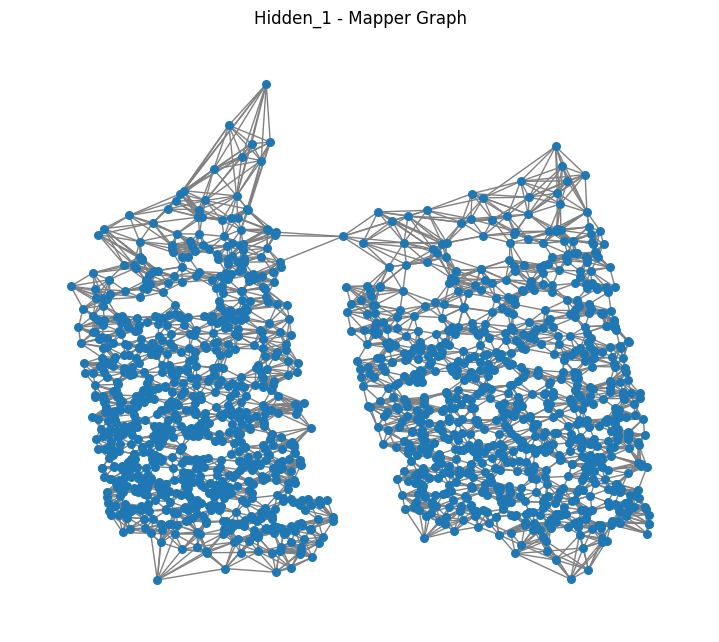

Analyzing Hidden_2 activations...


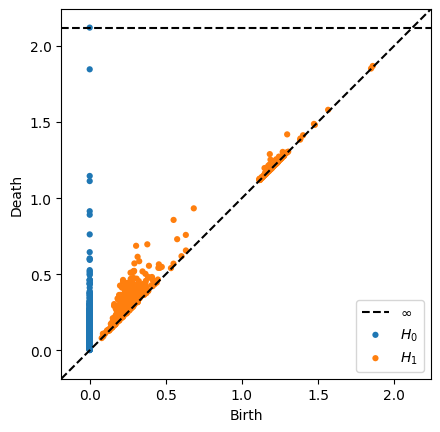

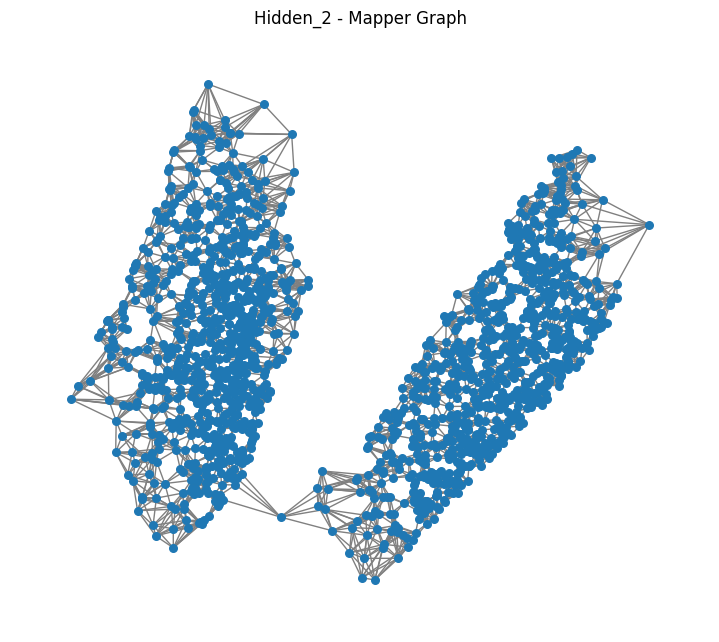

In [105]:
activations = extract_activations_gadget(ff_uncertain_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")

## Seperated Homology Analysis

1. Loops persisting longer in `longer_duration_trials` suggest sustained neural activity patterns, possibly indicating difficulty in switching away from stress-induced cognitive states.

2. More spread out birth time of these high dimensional cyclic components

3. If using all of the data (stress/non_stress), the spread is more obvious.
    - Higher variance in stressful trials means more variation in cyclic patterns.
    - If LC-NE responses fluctuate more under stress, the model fails to stabilize activations, increasing variance. Phasic NE bursts might cause chaotic transitions rather than smooth changes.


We will start with Wasserstein distance test comparison:

- The Wasserstein distance (also known as the Earth Mover’s Distance, EMD) measures the difference between two probability distributions by quantifying the amount of "work" required to transform one distribution into another.

- After computing persistence diagrams with Ripser, we get sets of birth-death pairs representing the topological features of activations. Since these diagrams are essentially point clouds, the Wasserstein distance tells us:
    - 1️⃣ How different are the topological structures of activations between conditions?
    - 2️⃣ Do stressful activations create more persistent loops/components?
    - 3️⃣ Can we quantify significant shifts in activation topology?

In [106]:
activations_long = extract_activations_gadget(ff_uncertain_gadget, X_long_test)
activations_short = extract_activations_gadget(ff_uncertain_gadget, X_short_test)
activations_neutral = extract_activations_gadget(ff_uncertain_gadget, X_neutral_test)
activations_stress = extract_activations_gadget(ff_uncertain_gadget, X_stress_test)

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([171, 256])
Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([170, 256])
Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([171, 256])
Adjusting prev_LC size: torch.Size([171, 256]) -> torch.Size([170, 256])


In [107]:
activations_dict = {
    # "Long Duration": activations_long,
    # "Short Duration": activations_short,
    "Neutral": activations_neutral,
    "Stressful": activations_stress
}

df_persistence_distances = compute_persistence_distance_df(activations_dict)
df_ne = df_persistence_distances[df_persistence_distances["Key"] == "NE"]
df_ne

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/persim/wasserstein.py:51: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/persim/wasserstein.py:61: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/l

,Key,Condition 1,Condition 2,Wasserstein H0,Wasserstein H1
1,NE,Neutral,Stressful,5.528057,2.371761


Empirical Baselines for Wasserstein test:
* Smaller than 0.1 → Nearly identical distributions.
* From 0.1 - 0.3 → Small but noticeable difference.
* From 0.3 - 0.6 → Moderate effect, possibly meaningful.
* Greater than 0.6 → Large divergence, likely significant.

In [108]:
df_results = compute_persistence_hypothesis_test(activations_dict, n_permutations=1000, check_for=['NE','LC'])

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Smallest p-value possible is $\frac{1}{\text{number of permutations}}$

In [109]:
df_results

,Key,Condition 1,Condition 2,Wasserstein H0,p-value H0,Wasserstein H1,p-value H1
0,NE,Neutral,Stressful,5.528057,0.001998,2.371761,0.001998
1,LC,Neutral,Stressful,4.136886,0.001998,1.432850,0.001998


The distance for each are statsitcally different. However, we want to reason about the distribution. Let's again examine the life-time of connected components distribution directly with KS statistics and the `Kolmogorov-Smirnov (KS) test`. The two-sample K-S test is a generalization of the one-sample K-S test. Given  

$$
X_1, X_2, \dots, X_n \sim F_X \quad \text{and} \quad Y_1, Y_2, \dots, Y_m \sim F_Y
$$

and the hypotheses  

$$
H_0: F_X = F_Y \quad \text{vs} \quad H_a: F_X \neq F_Y
$$

the test statistic is given by  

$$
D_{n,m} = \sup_x \left| \hat{F}_n(x) - \hat{F}_m(x) \right|
$$

where $\hat{F}_n(x)$ and $\hat{F}_m(x)$ are the empirical distribution functions of $X_1, X_2, \dots, X_n$ and $Y_1, Y_2, \dots, Y_m$, respectively.

Intuitively, the KS test statistic measures the **maximum vertical distance** of CDF.

Analyzing LC activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


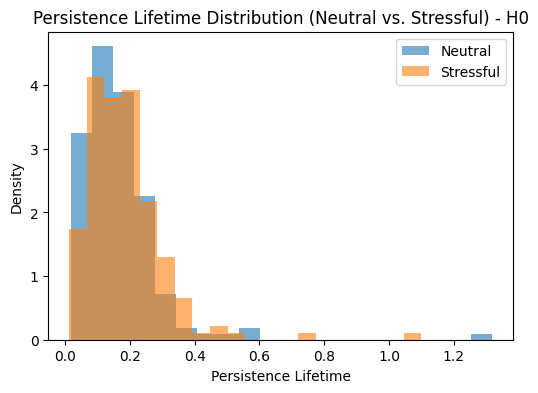

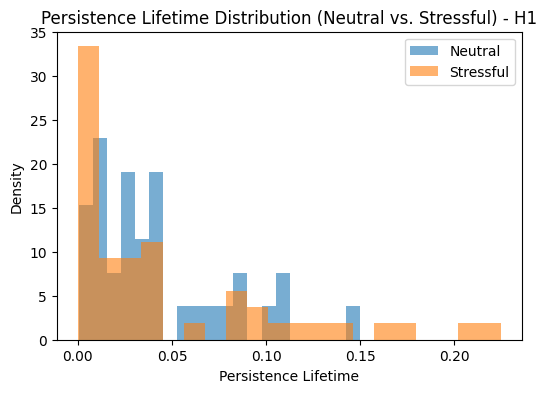

  Dimension Condition 1 Condition 2  Mean Lifetime 1  Mean Lifetime 2  \
0        H0     Neutral   Stressful         0.165494         0.188232   
1        H1     Neutral   Stressful         0.042472         0.048081   

    KS Stat  KS p-value  t-test Stat  t-test p-value  
0  0.143857    0.054157    -1.649728        0.099930  
1  0.302381    0.038034    -0.537875        0.592177  
Analyzing NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


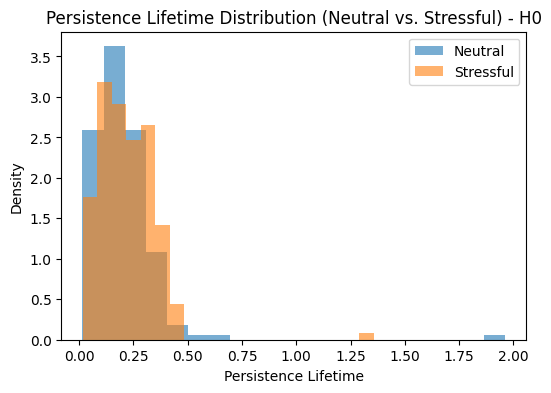

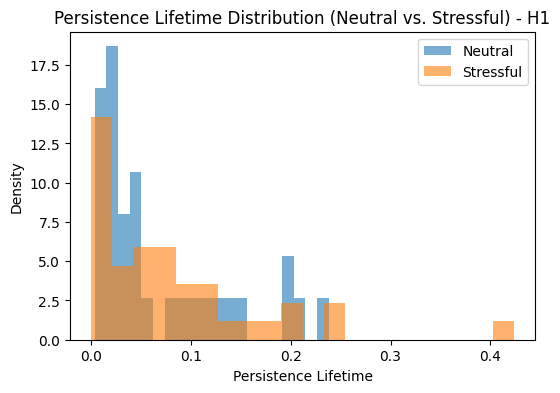

  Dimension Condition 1 Condition 2  Mean Lifetime 1  Mean Lifetime 2  \
0        H0     Neutral   Stressful         0.201193         0.221975   
1        H1     Neutral   Stressful         0.067468         0.082808   

   KS Stat  KS p-value  t-test Stat  t-test p-value  
0  0.15503    0.031051    -1.214865        0.225303  
1  0.19375    0.462936    -0.826685        0.411233  
Analyzing Tonic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


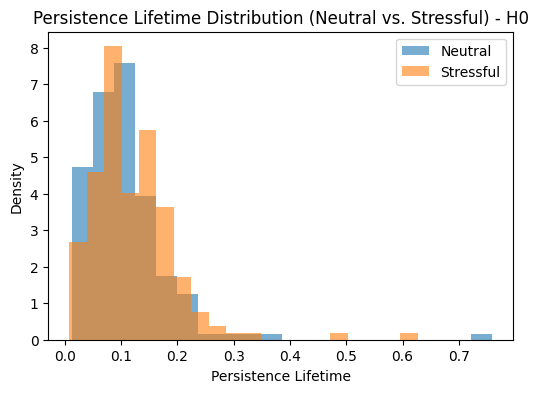

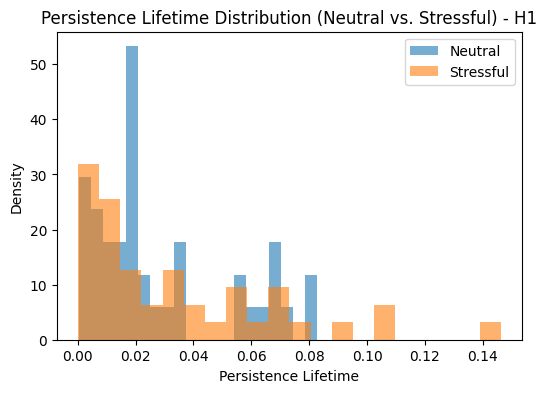

  Dimension Condition 1 Condition 2  Mean Lifetime 1  Mean Lifetime 2  \
0        H0     Neutral   Stressful         0.106736         0.121130   
1        H1     Neutral   Stressful         0.028646         0.033884   

    KS Stat  KS p-value  t-test Stat  t-test p-value  
0  0.161190    0.022204    -1.714272        0.087398  
1  0.128191    0.823760    -0.809230        0.420923  
Analyzing Phasic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


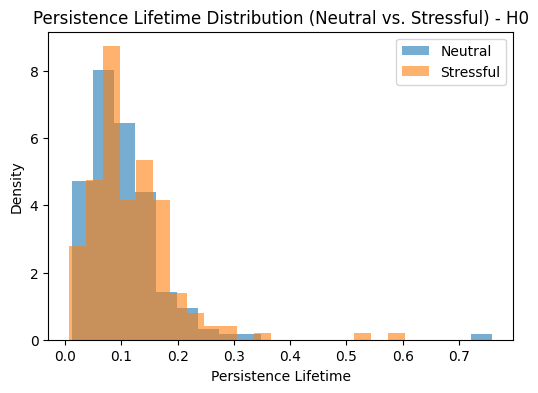

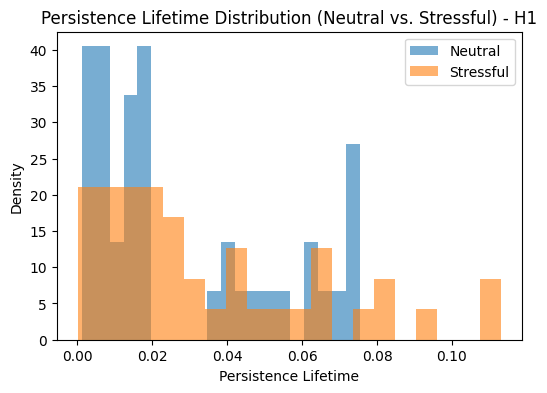

  Dimension Condition 1 Condition 2  Mean Lifetime 1  Mean Lifetime 2  \
0        H0     Neutral   Stressful         0.102647          0.11814   
1        H1     Neutral   Stressful         0.027974          0.03493   

    KS Stat  KS p-value  t-test Stat  t-test p-value  
0  0.148799    0.042772    -1.876415        0.061463  
1  0.220238    0.226127    -1.124487        0.264228  
Analyzing Hidden_1 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


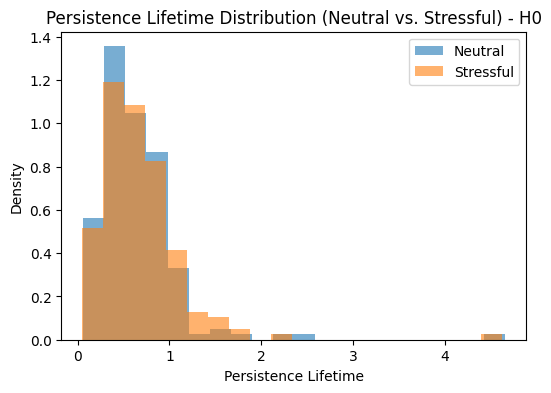

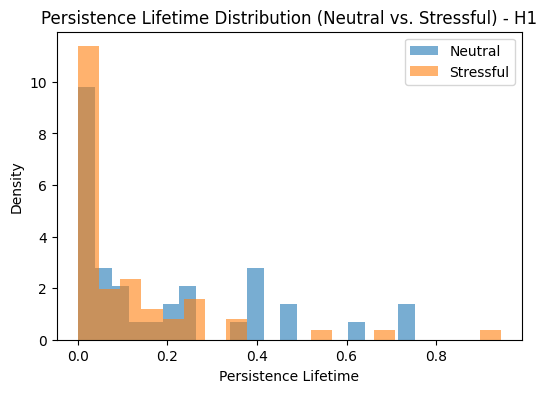

  Dimension Condition 1 Condition 2  Mean Lifetime 1  Mean Lifetime 2  \
0        H0     Neutral   Stressful         0.635956         0.683706   
1        H1     Neutral   Stressful         0.186150         0.119719   

    KS Stat  KS p-value  t-test Stat  t-test p-value  
0  0.077898    0.647464    -0.937400        0.349224  
1  0.191033    0.336722     1.560748        0.123092  
Analyzing Hidden_2 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


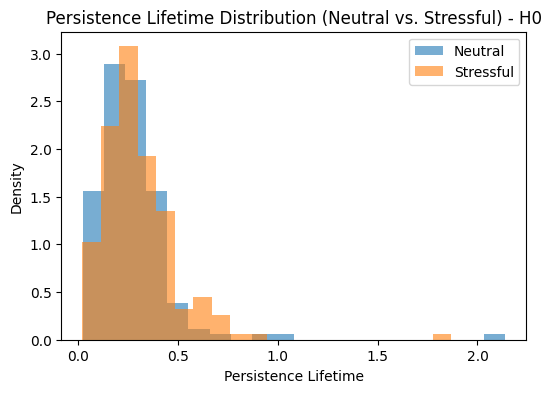

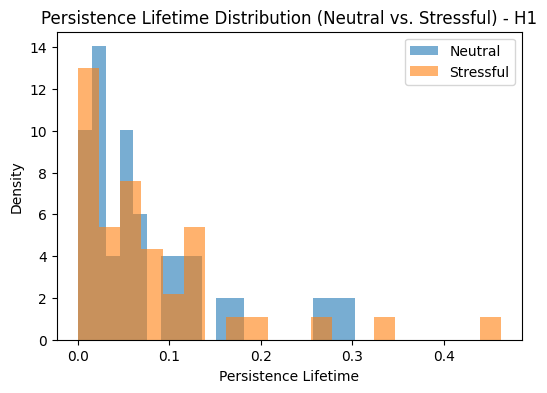

  Dimension Condition 1 Condition 2  Mean Lifetime 1  Mean Lifetime 2  \
0        H0     Neutral   Stressful         0.271822         0.305797   
1        H1     Neutral   Stressful         0.079669         0.080952   

    KS Stat  KS p-value  t-test Stat  t-test p-value  
0  0.131257    0.099379    -1.549545        0.122190  
1  0.137879    0.821045    -0.062982        0.949958  


In [110]:
for key in activations_long.keys():
    print(f"Analyzing {key} activations...")
    diagrams_neutral = ripser(activations_neutral[key])['dgms']
    diagrams_stressful = ripser(activations_stress[key])['dgms']

    df_lifetime_persistence_results = compare_persistence_lifetimes(diagrams_neutral, diagrams_stressful, "Neutral", "Stressful")
    print(df_lifetime_persistence_results)

Let's look at the birth and death distribution of each higher order cyclic components formed in the actiavtion space

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:660: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(birth_times[cond], label=f"{cond} - Birth", shade=True)
/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:660: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(birth_times[cond], label=f"{cond} - Birth", shade=True)


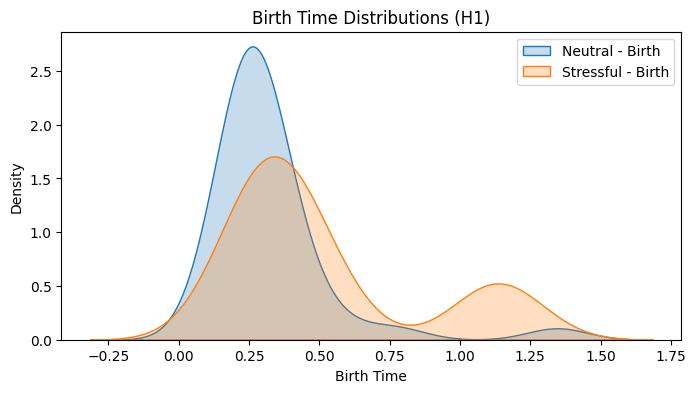

/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:670: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(death_times[cond], label=f"{cond} - Death", shade=True)
/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:670: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(death_times[cond], label=f"{cond} - Death", shade=True)


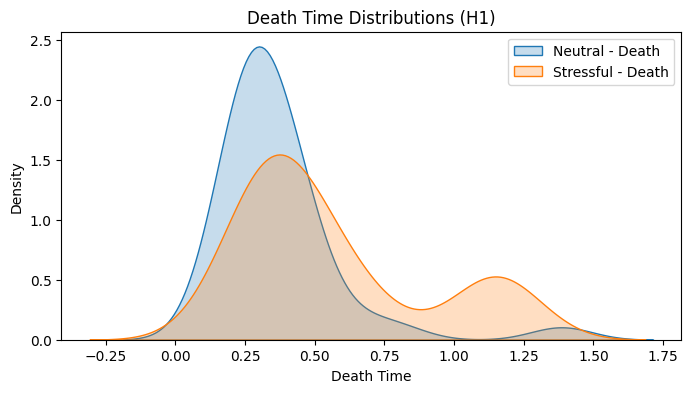

In [111]:
# plot_birth_death_distributions(activations_dict, conditions=("Neutral", "Stressful"), activation_name='LC', homology_dim=0)
plot_birth_death_distributions(activations_dict, conditions=("Neutral", "Stressful"), activation_name='LC', homology_dim=1)

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:660: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(birth_times[cond], label=f"{cond} - Birth", shade=True)
/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:660: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(birth_times[cond], label=f"{cond} - Birth", shade=True)


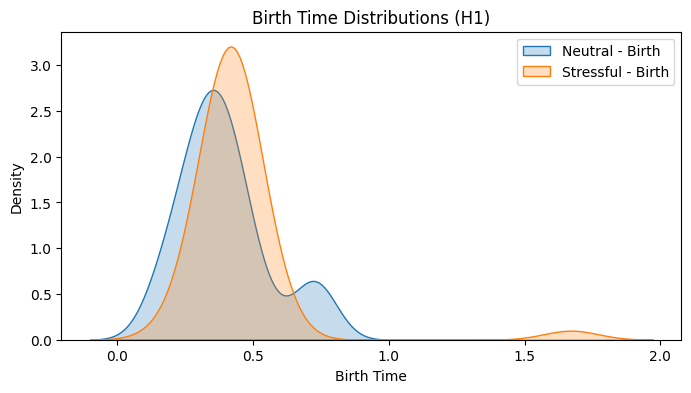

/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:670: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(death_times[cond], label=f"{cond} - Death", shade=True)
/Users/kevinb/Desktop/cogs164/Blue-Dot-Project/analysis/analysis.py:670: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(death_times[cond], label=f"{cond} - Death", shade=True)


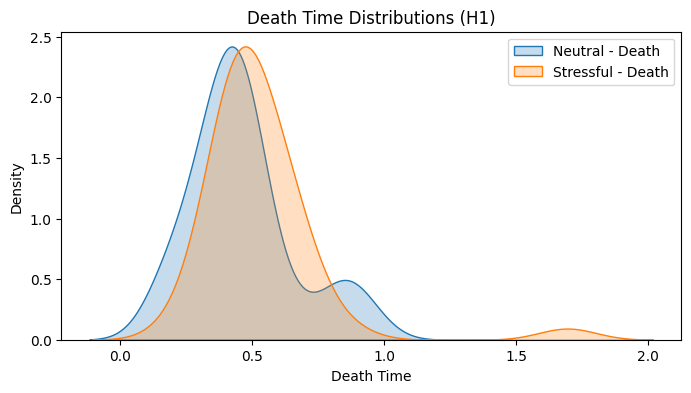

In [112]:
plot_birth_death_distributions(activations_dict, conditions=("Neutral", "Stressful"), activation_name='NE', homology_dim=1)

Let's see how different these distributions are and we will be using two non-parametric test: `Kolmogorov-Smirnov (KS) test` and `Mann-Whitney U test`

In [113]:
hypothesis_test_persistence_distributions(activations_dict, conditions=("Neutral", "Stressful"), activation_name='LC', homology_dim=0)
hypothesis_test_persistence_distributions(activations_dict, conditions=("Neutral", "Stressful"), activation_name='LC', homology_dim=1)


Hypothesis Test Results For Homology H0:
Birth (H0) → KS p=1.0000, MW p=1.0000
Death (H0) → KS p=0.0552, MW p=0.0277

Hypothesis Test Results For Homology H1:
Birth (H1) → KS p=0.0041, MW p=0.0004
Death (H1) → KS p=0.0052, MW p=0.0015


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


[{'Metric': 'Birth (H1)',
  'KS Test Stat': np.float64(0.37857142857142856),
  'KS p-value': np.float64(0.004065959395982987),
  'MW Test Stat': np.float64(455.0),
  'MW p-value': np.float64(0.00039168459649513855)},
 {'Metric': 'Death (H1)',
  'KS Test Stat': np.float64(0.37083333333333335),
  'KS p-value': np.float64(0.005203708481705719),
  'MW Test Stat': np.float64(495.0),
  'MW p-value': np.float64(0.0014892587102403397)}]

In [114]:
hypothesis_test_persistence_distributions(activations_dict, conditions=("Neutral", "Stressful"), activation_name='NE', homology_dim=0)
hypothesis_test_persistence_distributions(activations_dict, conditions=("Neutral", "Stressful"), activation_name='NE', homology_dim=1)


Hypothesis Test Results For Homology H0:
Birth (H0) → KS p=1.0000, MW p=1.0000
Death (H0) → KS p=0.0318, MW p=0.0240

Hypothesis Test Results For Homology H1:
Birth (H1) → KS p=0.0318, MW p=0.0408
Death (H1) → KS p=0.1459, MW p=0.0689


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


[{'Metric': 'Birth (H1)',
  'KS Test Stat': np.float64(0.33125),
  'KS p-value': np.float64(0.0317948791151543),
  'MW Test Stat': np.float64(459.0),
  'MW p-value': np.float64(0.04080469369196476)},
 {'Metric': 'Death (H1)',
  'KS Test Stat': np.float64(0.2625),
  'KS p-value': np.float64(0.1458579404387256),
  'MW Test Stat': np.float64(479.0),
  'MW p-value': np.float64(0.06893280916644293)}]

We  can look at the graphical representations

In [115]:
# for key in activations_long.keys():
#     print(f"Analyzing {key} activations...")

#     act_long = activations_long[key]
#     act_short = activations_short[key]

#     compute_persistent_homology_overlay(act_long, act_short, title=f"{key} - Persistent Homology (Long duration vs. Short duration)")
#     compute_mapper_graph_overlay(act_long, act_short, title=f"{key} - Mapper Graph (Long duration vs. Short duration)")

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Analyzing LC activations...


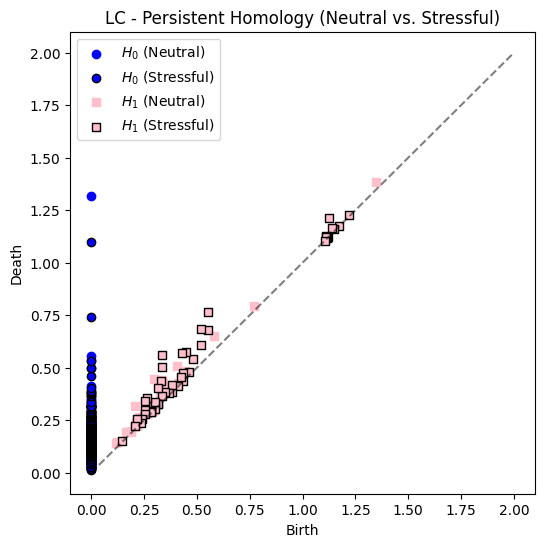

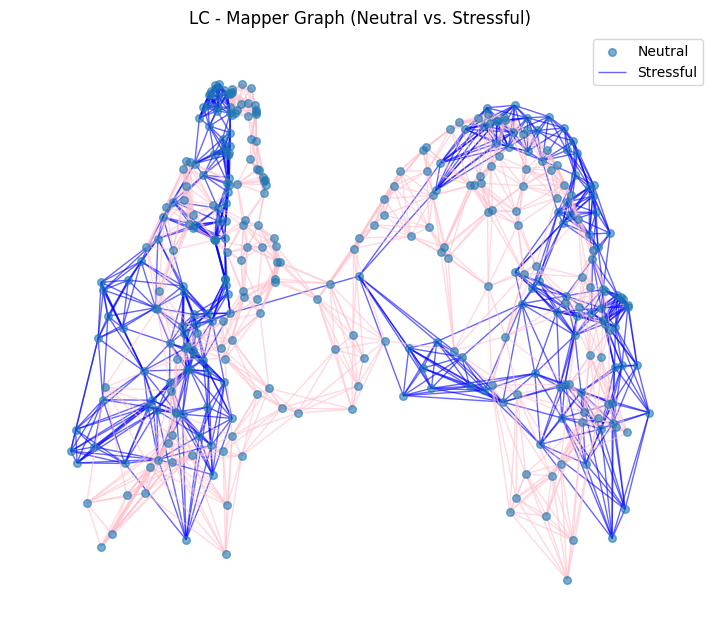

Analyzing NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


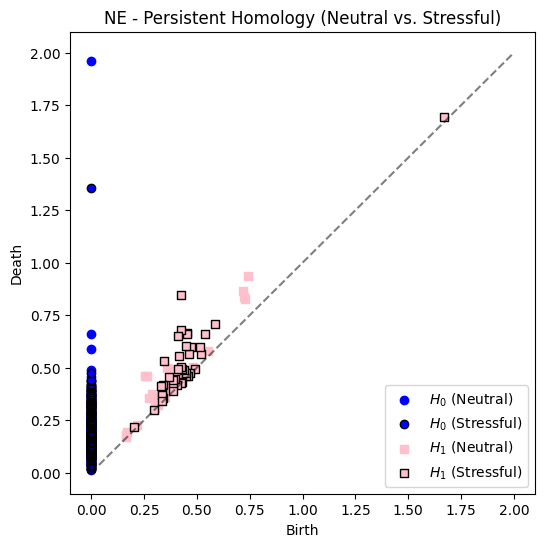

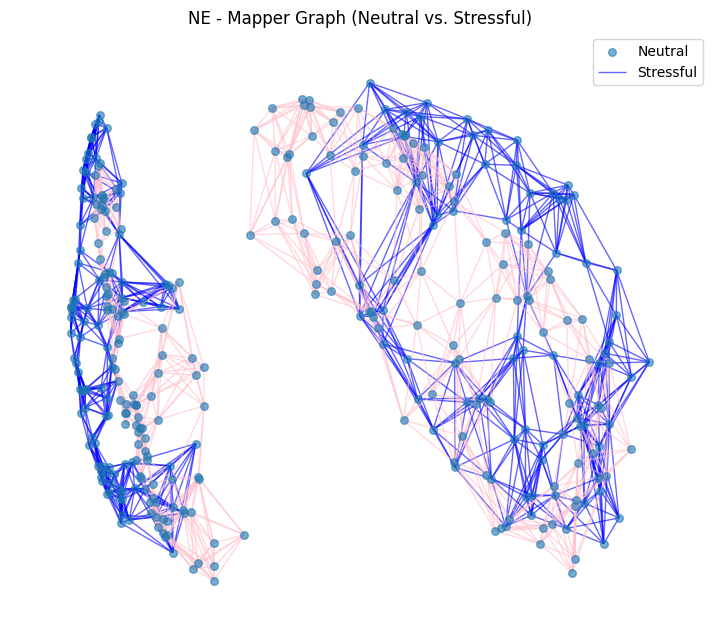

Analyzing Tonic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


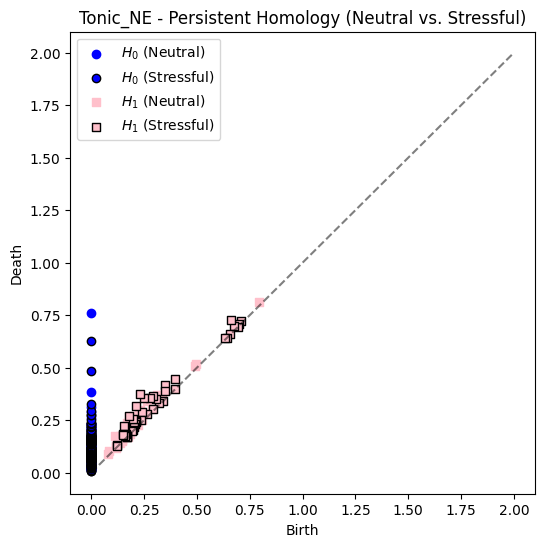

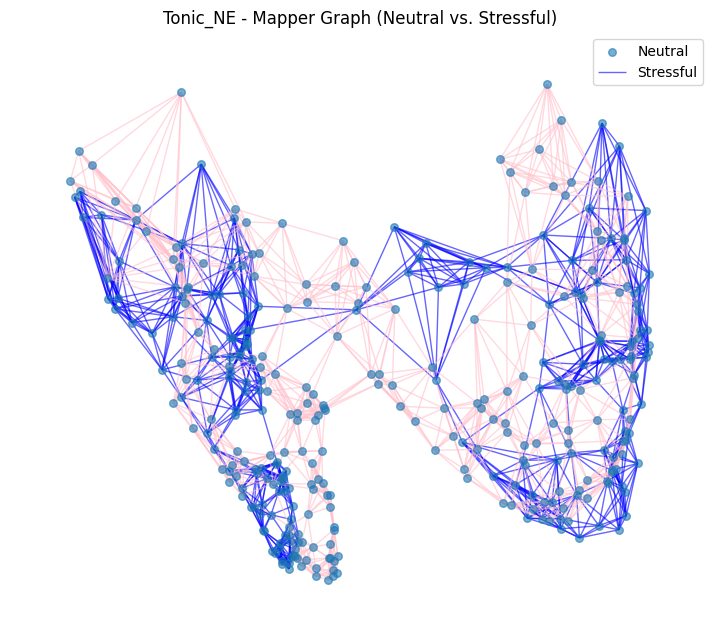

Analyzing Phasic_NE activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


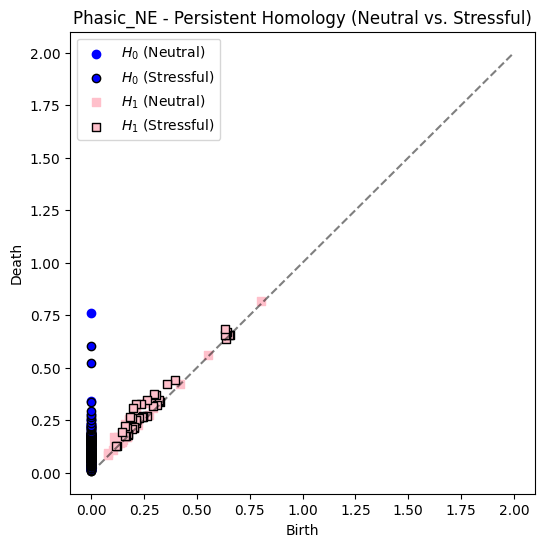

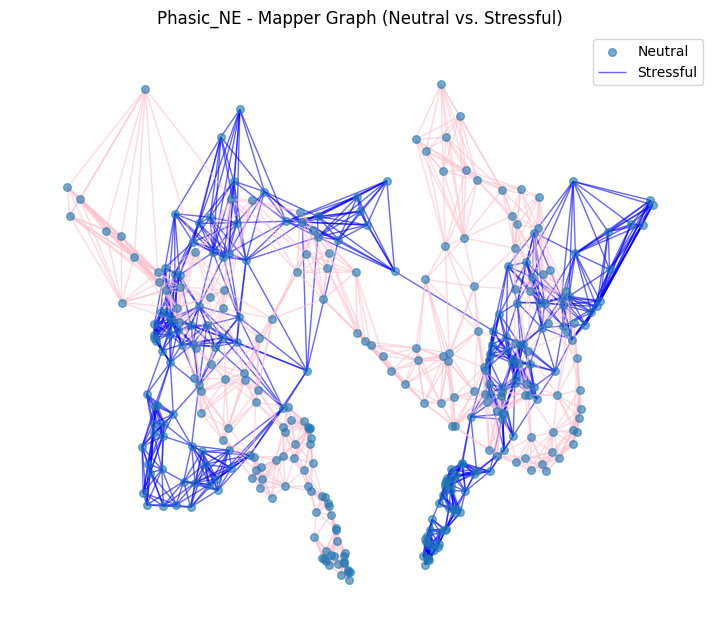

Analyzing Hidden_1 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


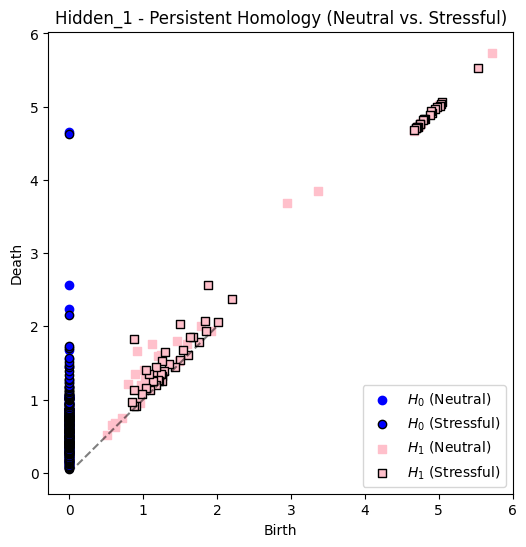

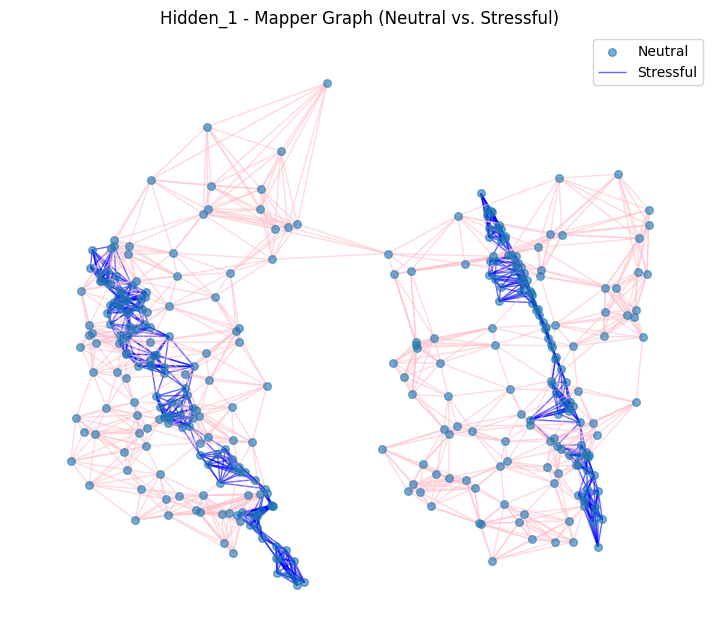

Analyzing Hidden_2 activations...


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


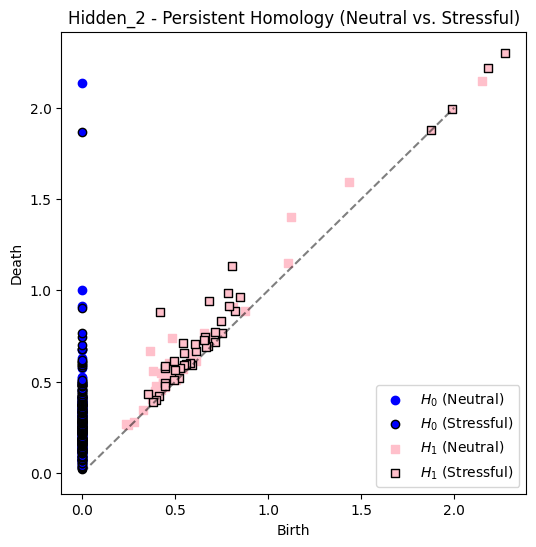

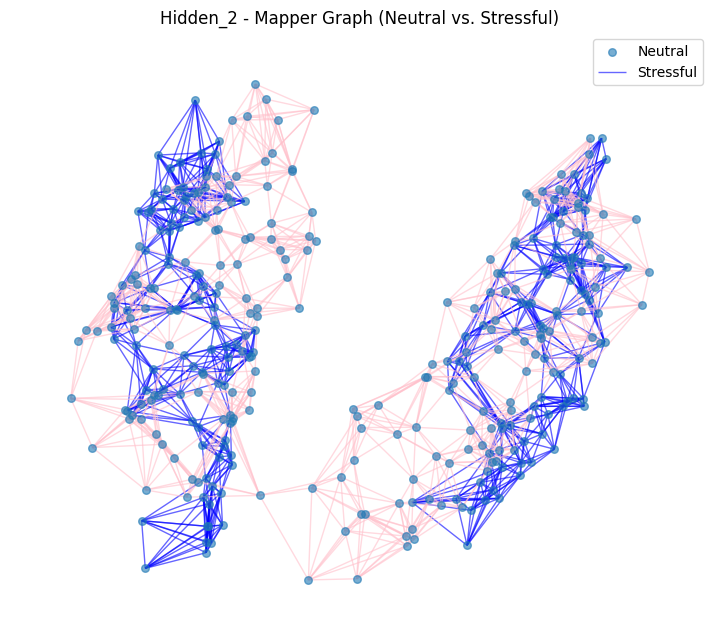

In [116]:
for key in activations_neutral.keys():
    print(f"Analyzing {key} activations...")

    act_neutral = activations_neutral[key]
    act_stress = activations_stress[key]

    compute_persistent_homology_overlay(act_neutral, act_stress, title=f"{key} - Persistent Homology (Neutral vs. Stressful)")

    compute_mapper_graph_overlay(act_neutral, act_stress, title=f"{key} - Mapper Graph (Neutral vs. Stressful)")

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


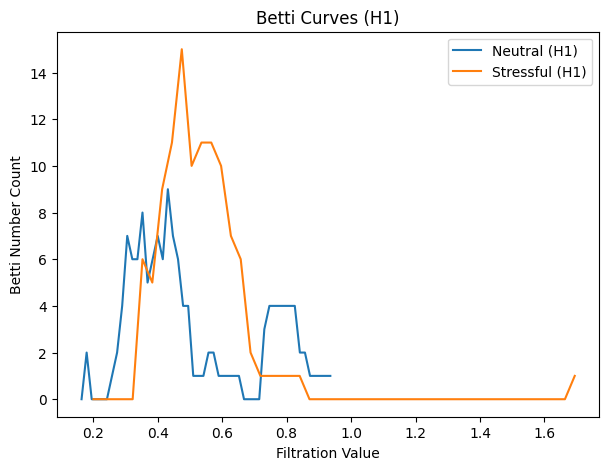

In [117]:
compute_betti_curves(activations_dict, homology_dim=1,  activation_name='NE')

> Stressful Condition:
- Higher peak Betti numbers → Stronger presence of loops.
- Longer persistence of loops at lower filtration values → More sustained recurrence patterns.
- Rapid drop-off after ~0.7 → These loops exist early but disappear quickly.

> Neutral Condition:
- Lower peak Betti numbers → Fewer loops at the same filtration scale.
- More evenly distributed across filtration values → Suggests a more fluid or adaptive topology.


> Interpretations:
- Higher early Betti numbers in stress → More self-reinforcing cyclic structures, potentially reflecting cognitive fixation or repetitive thought loo.ps
- Neutral has a more gradual decay → Supports greater cognitive flexibility, avoiding getting stuck in self-repeating cycles.
- Stress curves drop sharply → Possible instability or sudden disruptions in these loops, rather than smooth transitions.

## Temporal Auto-Correlation

- Both Neutral (blue) and Stressful (orange) conditions decay quickly, suggesting that the effect of past states diminishes over time.

- The Stressful condition seems to have **slightly higher auto-correlation** for later lags, possibly indicating **more prolonged activation states**.

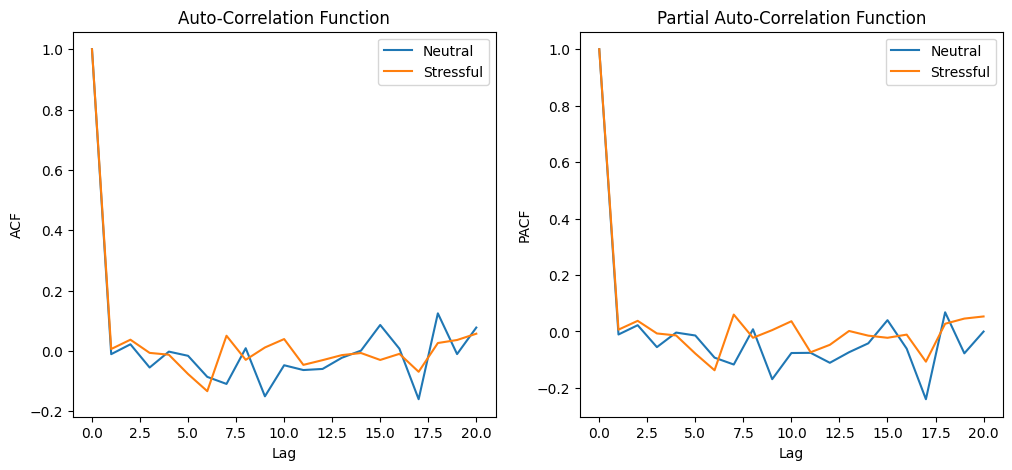

In [118]:
compute_autocorrelation(activations_dict, conditions=("Neutral", "Stressful"), activation_name='LC')

## KL Divergence Entropy Between Stress and Neutral

In [119]:
compute_activation_entropy(activations_dict, conditions=("Neutral", "Stressful"), activation_name='LC')


Entropy & Divergence Results:
Neutral Entropy: 2.9560
Stressful Entropy: 2.8926
KL-Divergence (Neutral → Stressful): 0.0091


({'Neutral': np.float64(2.9559617409074206),
  'Stressful': np.float64(2.8925571055562496)},
 np.float64(0.009086150991952778))

In [120]:
compute_activation_entropy(activations_dict, conditions=("Neutral", "Stressful"), activation_name='NE')


Entropy & Divergence Results:
Neutral Entropy: 3.0573
Stressful Entropy: 3.0872
KL-Divergence (Neutral → Stressful): 0.0076


({'Neutral': np.float64(3.057260173704733),
  'Stressful': np.float64(3.0871800917515877)},
 np.float64(0.007555248527380544))

# Time-delayed Persistent Homology With Takens’ Embedding Theorem
1. Captures `Temporal Structures` → Instead of analyzing activations instantaneously, time-delay embedding constructs trajectories that capture the evolution of activations.

2. Enhances `Topological Features` → Adds loops (H₁) and higher-dimensional features that may not be visible in raw activations.

3. Detects `Recurrence & Stability` → If neural activations cycle or oscillate, these will appear as persistent loops.

In [121]:
activations_neutral['LC'].shape

(171, 256)

`Test data size` x `hidden size`

/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/ripser/ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


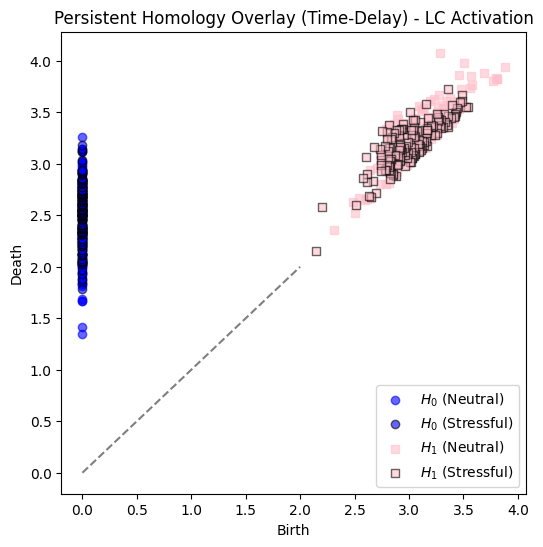

In [122]:
embedded_neutral_LC = time_delay_embedding_multidim(np.asarray(activations_neutral['LC']), delay=5, dimension=3)
embedded_stress_LC = time_delay_embedding_multidim(np.asarray(activations_stress['LC']), delay=5, dimension=3)

compute_persistent_homology_overlay_with_delay(
    embedded_neutral_LC, embedded_stress_LC, 
    title="Persistent Homology Overlay (Time-Delay) - LC Activation"
)

# Experiments Setting Modification

In [123]:
from analysis.analysis import (analyze_uncertainty_relationships,
                               simulate_lc_activation,
                               analyze_uncertainty_relationships_heatmap)

In [124]:
X_tensor.shape, Y_tensor.shape

(torch.Size([1699, 7]), torch.Size([1699]))

Adjusting prev_LC size: torch.Size([170, 256]) -> torch.Size([1699, 256])


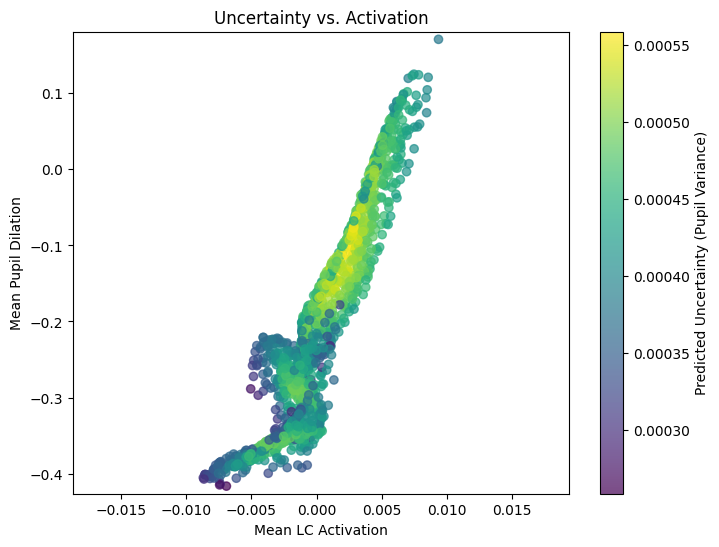

In [125]:
analyze_uncertainty_relationships_heatmap(ff_uncertain_gadget, X_tensor)

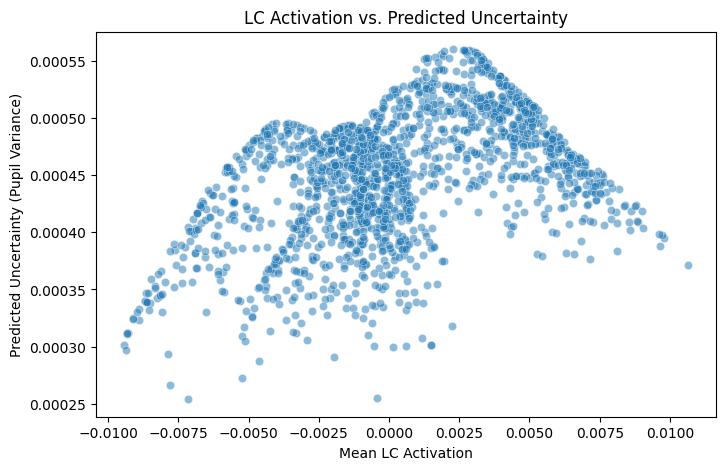

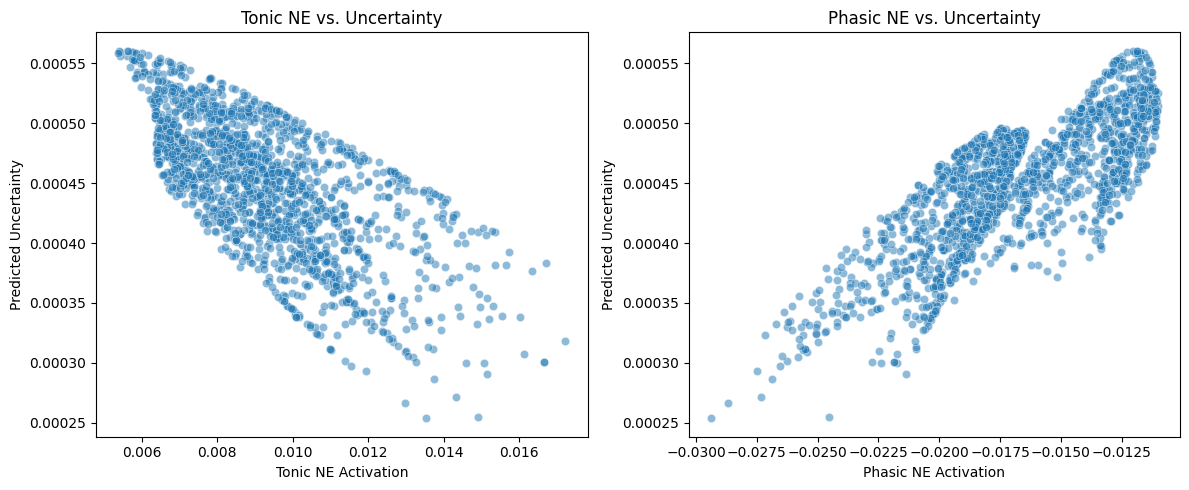


Correlation Results:
LC vs. Uncertainty: 0.4372
Tonic NE vs. Uncertainty: -0.6919
Phasic NE vs. Uncertainty: 0.8037
NE vs. Uncertainty: -0.2526


In [126]:
uncertainty_results = analyze_uncertainty_relationships(ff_uncertain_gadget, X_tensor)

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([340, 256])


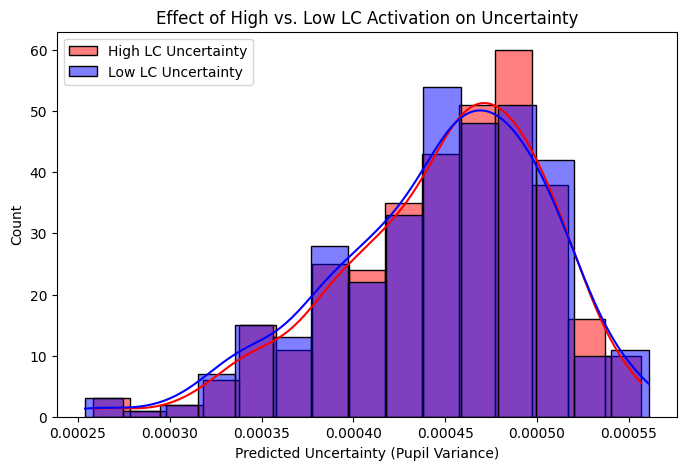

In [127]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.01)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()

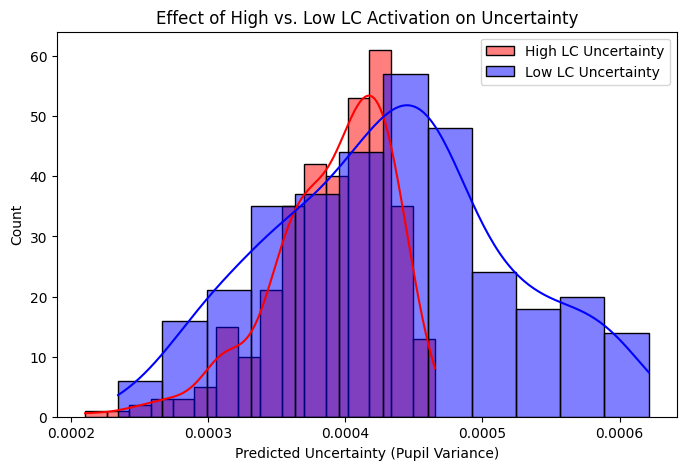

In [128]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.5)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()